In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)


In [3]:
df = pd.read_csv('water_potability.csv')


print(f"Shape of the dataset: {df.shape}")
display(df.shape)

print("Basic information about the dataset:")
df.info()



Shape of the dataset: (3276, 10)


(3276, 10)

Basic information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [4]:
display(df.head(10))

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
5,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,0
6,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,0
7,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,0
8,NaN,118.988579,14285.583854,7.804174,268.646941,389.375566,12.706049,53.928846,3.595017,0
9,11.180284,227.231469,25484.508491,9.077200,404.041635,563.885481,17.927806,71.976601,4.370562,0


In [5]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Numerical columns:")
print(numerical_cols)

Numerical columns:
['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability']


In [6]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


Class distribution for 'Potability':
Potability
0    1998
1    1278
Name: count, dtype: int64

Class distribution in percentage:
Potability
0    60.989011
1    39.010989
Name: proportion, dtype: float64


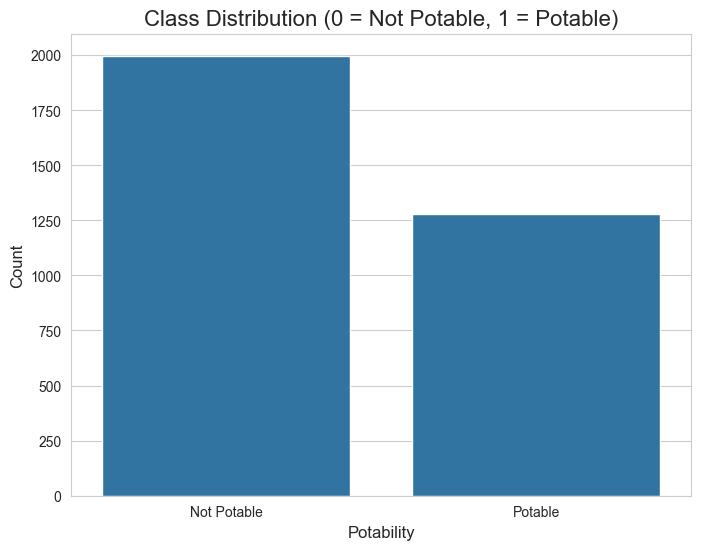

In [7]:
print("Class distribution for 'Potability':")
print(df['Potability'].value_counts())
print("\nClass distribution in percentage:")
print(df['Potability'].value_counts(normalize=True) * 100)

#
plt.figure(figsize=(8, 6))
sns.countplot(x='Potability', data=df)
plt.title('Class Distribution (0 = Not Potable, 1 = Potable)', fontsize=16)
plt.xlabel('Potability', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0, 1], ['Not Potable', 'Potable'])
plt.show()

In [8]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage (%)': missing_percentage
})

print("Missing values analysis:")
print(missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage (%)', ascending=False))

Missing values analysis:
                 Missing Count  Missing Percentage (%)
Sulfate                    781               23.840049
ph                         491               14.987790
Trihalomethanes            162                4.945055


In [9]:
print("Checking for invalid values (e.g., negatives where not possible):")
print(df.describe().loc[['min']])

Checking for invalid values (e.g., negatives where not possible):
      ph  Hardness      Solids  Chloramines  Sulfate  Conductivity  \
min  0.0    47.432  320.942611        0.352    129.0    181.483754   

     Organic_carbon  Trihalomethanes  Turbidity  Potability  
min             2.2            0.738       1.45         0.0  


In [10]:
numerical_features = df.drop('Potability', axis=1)

Q1 = numerical_features.quantile(0.25)
Q3 = numerical_features.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Create a boolean mask: True if a value is an outlier, False otherwise
# .any(axis=1) returns True for each row that contains at least one outlier
outlier_mask = ((numerical_features < lower_bound) | (numerical_features > upper_bound)).any(axis=1)

rows_with_outliers = df[outlier_mask]

print(f"Found {len(rows_with_outliers)} rows containing at least one outlier.")
print("\nDisplaying the first 10 rows with outliers:")

rows_with_outliers.head(10)

Found 325 rows containing at least one outlier.

Displaying the first 10 rows with outliers:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
9,11.180284,227.231469,25484.508491,9.077200,404.041635,563.885481,17.927806,71.976601,4.370562,0
18,8.975464,279.357167,19460.398131,6.204321,NaN,431.443990,12.888759,63.821237,2.436086,0
37,5.618064,304.235912,17281.975168,6.101084,NaN,399.471566,12.265002,81.588992,2.896547,0
43,9.920691,202.817483,9973.934059,6.882248,337.350529,333.192470,23.917601,71.833624,4.690707,0
51,7.809632,100.457615,12013.550629,5.212315,247.200826,605.220124,9.611349,66.084174,2.447444,0
61,6.391354,213.017830,20965.478309,5.375560,327.650543,369.338121,13.758105,17.915723,3.923749,0
66,5.058109,238.569380,34873.934523,8.983276,374.433505,669.725086,13.353181,76.521800,5.106656,0
67,NaN,103.464759,27420.167425,8.417305,NaN,485.974500,11.351133,67.869964,4.620793,0
71,5.704765,116.299330,33223.581529,7.050503,297.078153,504.378681,9.001820,48.147031,4.157533,0
80,1.844538,233.764343,28689.595778,7.724432,NaN,410.387264,15.611859,54.299444,5.013463,0


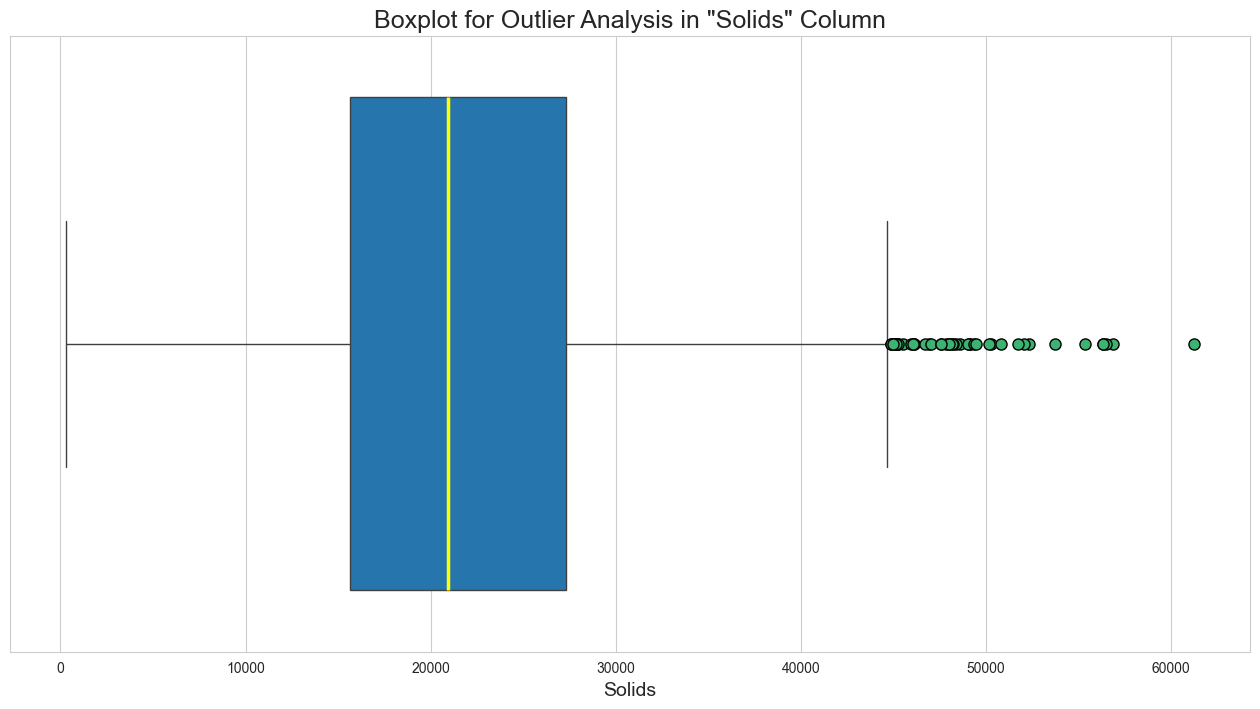

In [11]:
column_to_analyze = 'Solids'

# medianprops - styles the median line
# flierprops - styles the outlier markers (fliers)
medianprops = {'linestyle': '-', 'linewidth': 2.5, 'color': 'yellow'}
flierprops = {'marker': 'o', 'markerfacecolor': 'mediumseagreen', 'markersize': 8, 'markeredgecolor': 'black'}

plt.figure(figsize=(16, 8))
sns.boxplot(x=df[column_to_analyze],
            saturation=0.9,
            medianprops=medianprops,
            flierprops=flierprops)

plt.title(f'Boxplot for Outlier Analysis in "{column_to_analyze}" Column', fontsize=18)
plt.xlabel(column_to_analyze, fontsize=14)
plt.show()

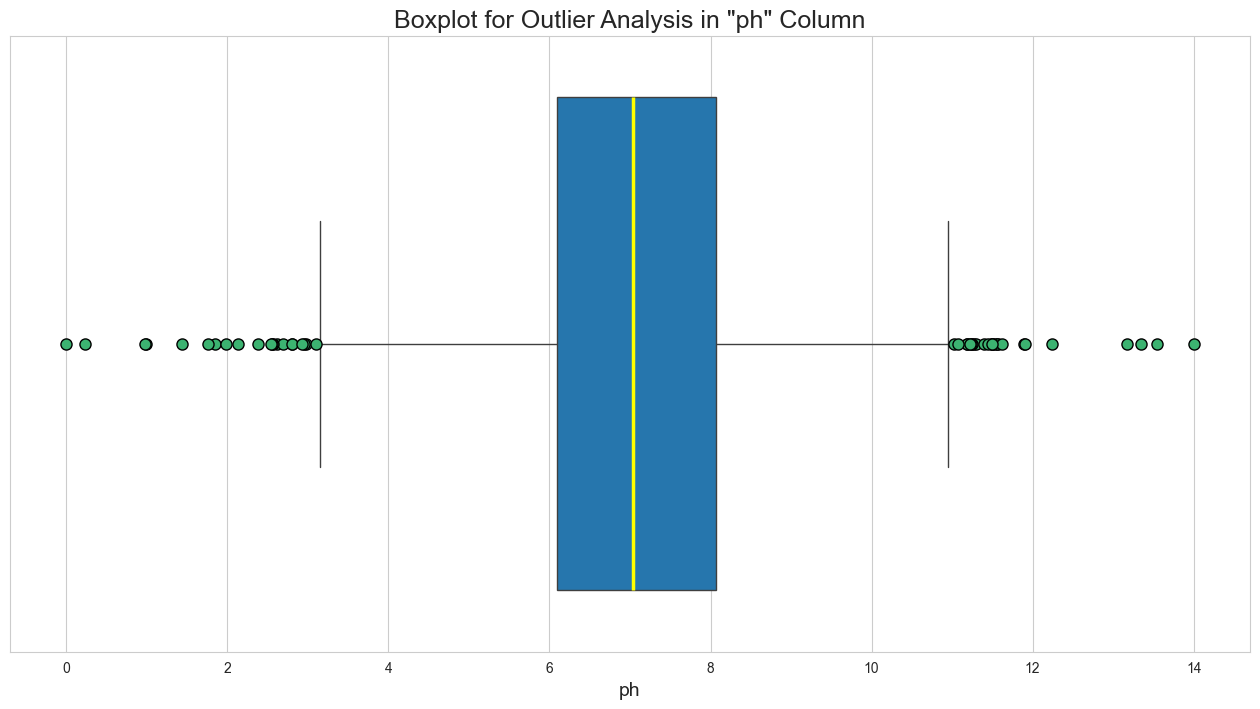

In [12]:
column_to_analyze = 'ph'

# medianprops - styles the median line
# flierprops - styles the outlier markers (fliers)
medianprops = {'linestyle': '-', 'linewidth': 2.5, 'color': 'yellow'}
flierprops = {'marker': 'o', 'markerfacecolor': 'mediumseagreen', 'markersize': 8, 'markeredgecolor': 'black'}

plt.figure(figsize=(16, 8))
sns.boxplot(x=df[column_to_analyze],
            saturation=0.9,
            medianprops=medianprops,
            flierprops=flierprops)

plt.title(f'Boxplot for Outlier Analysis in "{column_to_analyze}" Column', fontsize=18)
plt.xlabel(column_to_analyze, fontsize=14)
plt.show()

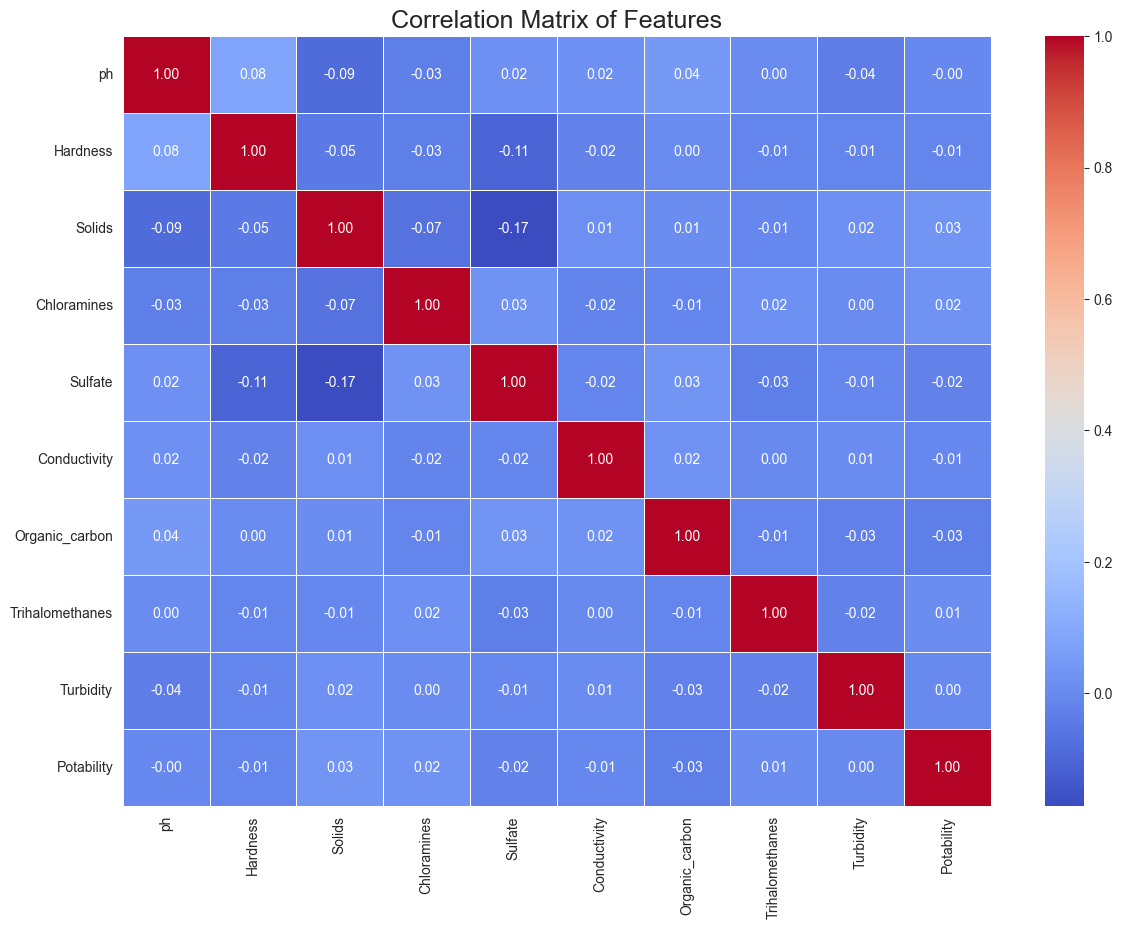


Analysis of the correlation matrix:
- There are no strong linear correlations between the input features (highest is ~0.13), which is good as it means we don't have multicollinearity.
- None of the individual features have a strong linear correlation with the target variable 'Potability'. This suggests that a model will need to learn complex, non-linear relationships to make accurate predictions.


In [13]:
correlation_matrix = df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features', fontsize=18)
plt.show()

print("\nAnalysis of the correlation matrix:")
print("- There are no strong linear correlations between the input features (highest is ~0.13), which is good as it means we don't have multicollinearity.")
print("- None of the individual features have a strong linear correlation with the target variable 'Potability'. This suggests that a model will need to learn complex, non-linear relationships to make accurate predictions.")

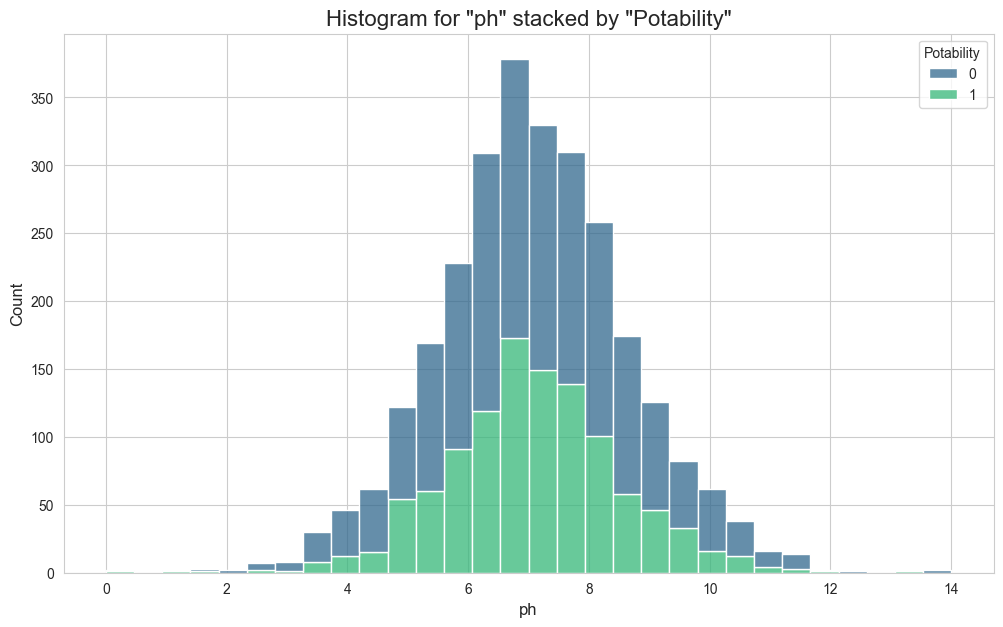

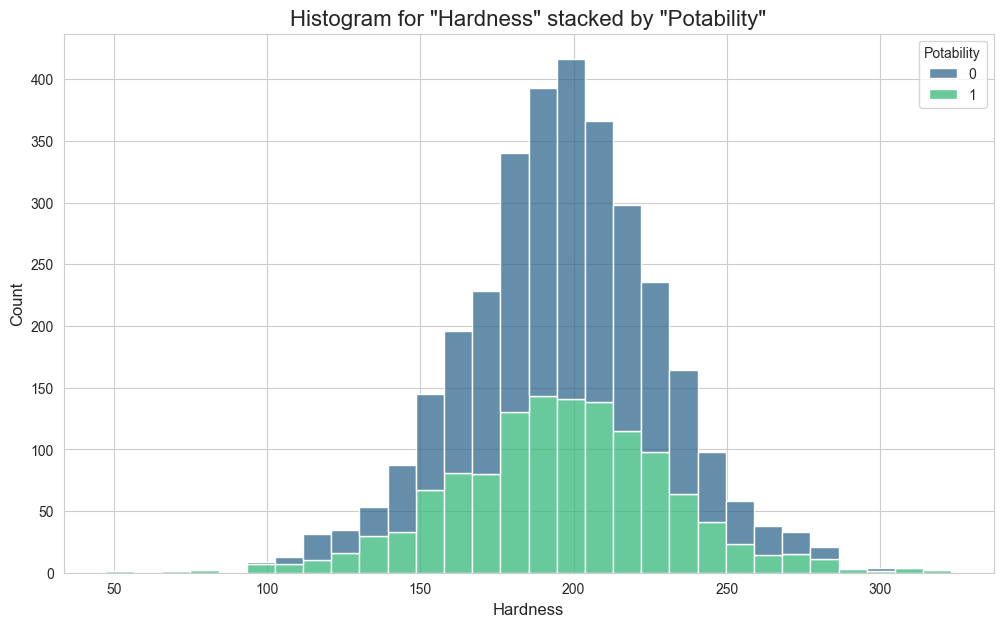

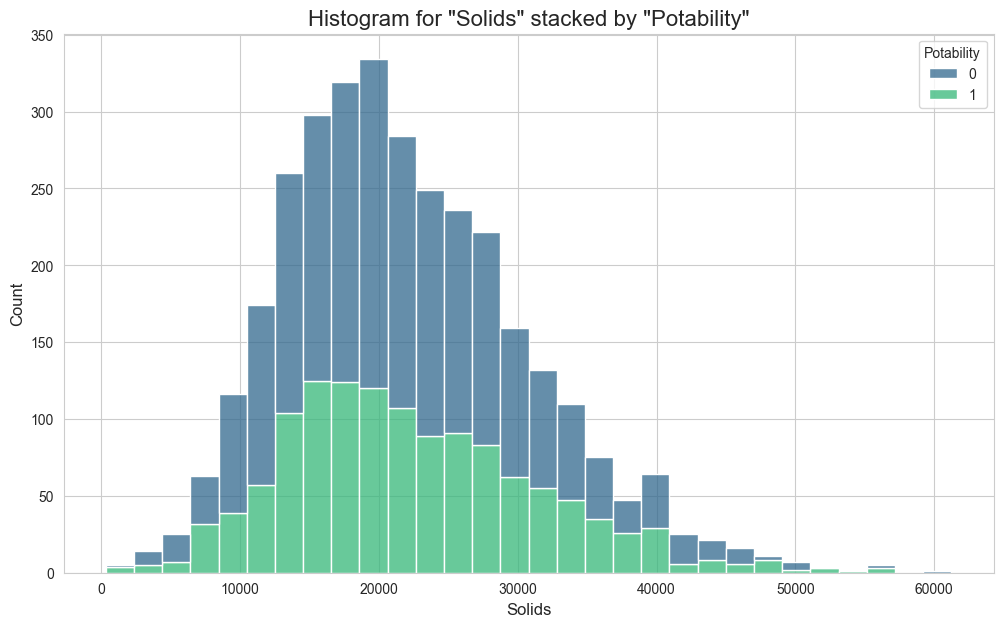

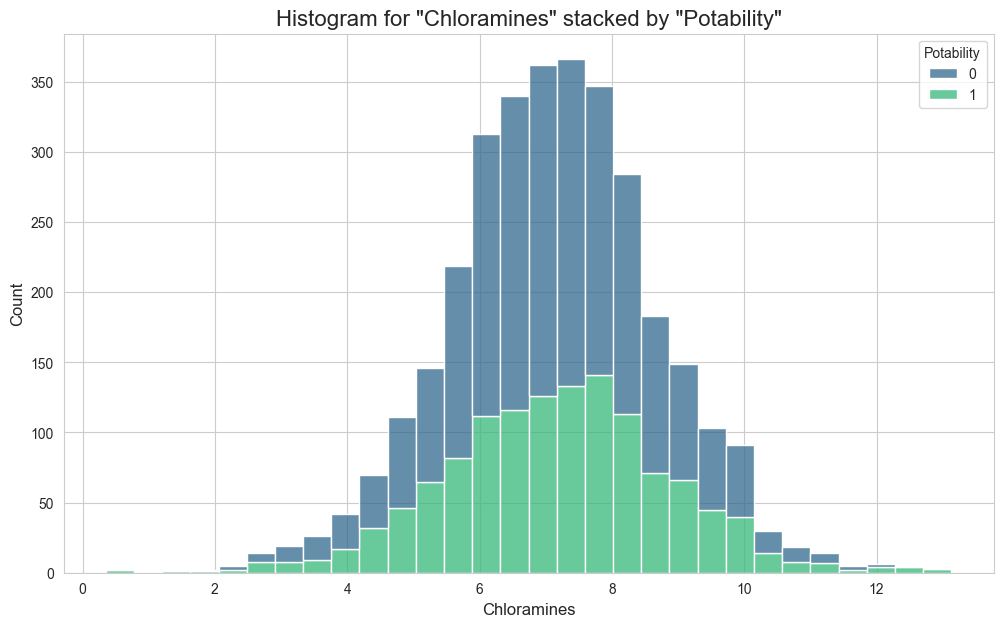

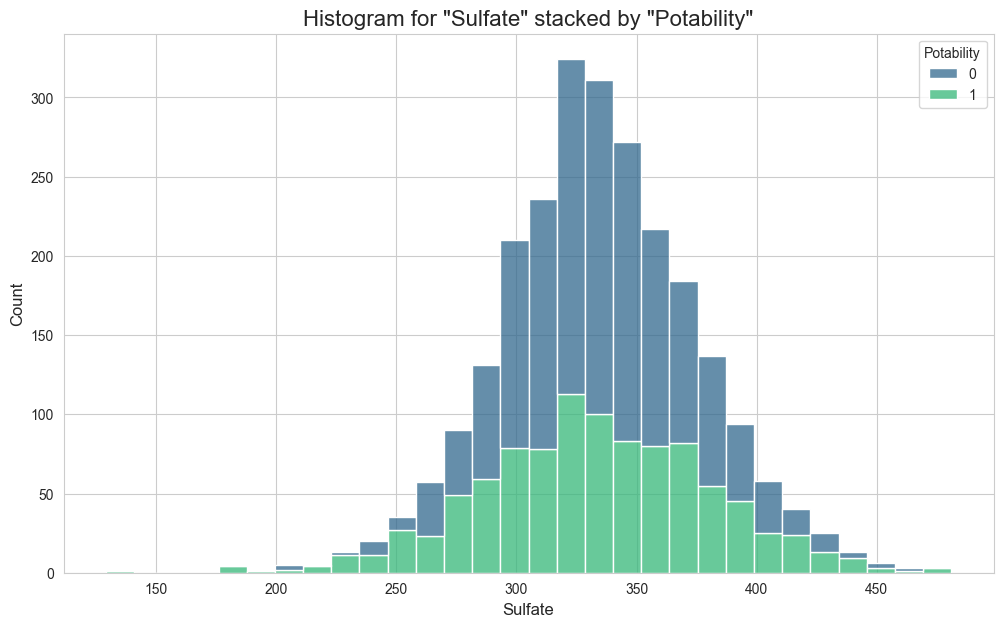

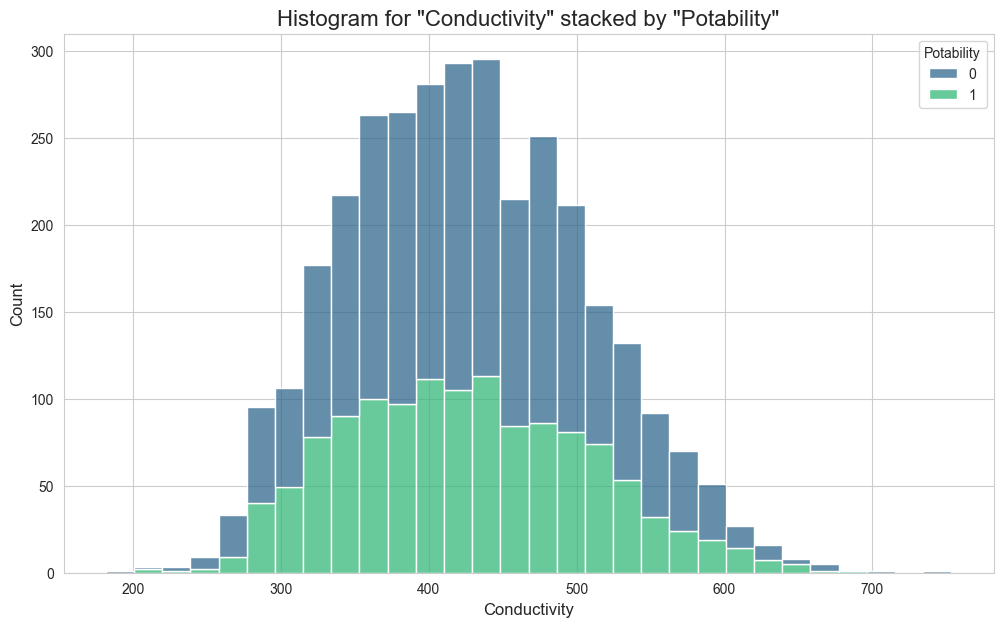

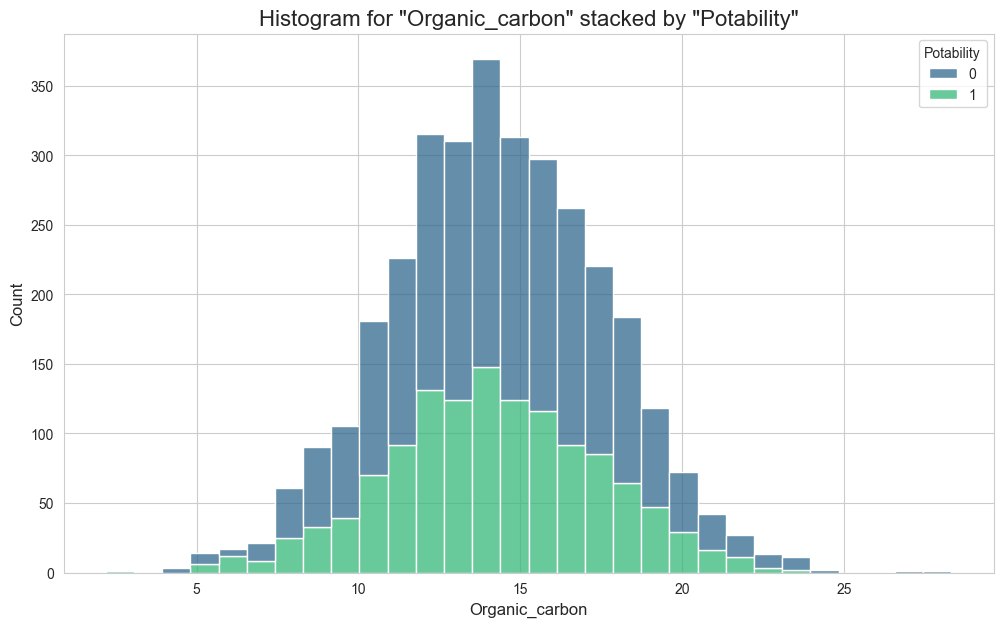

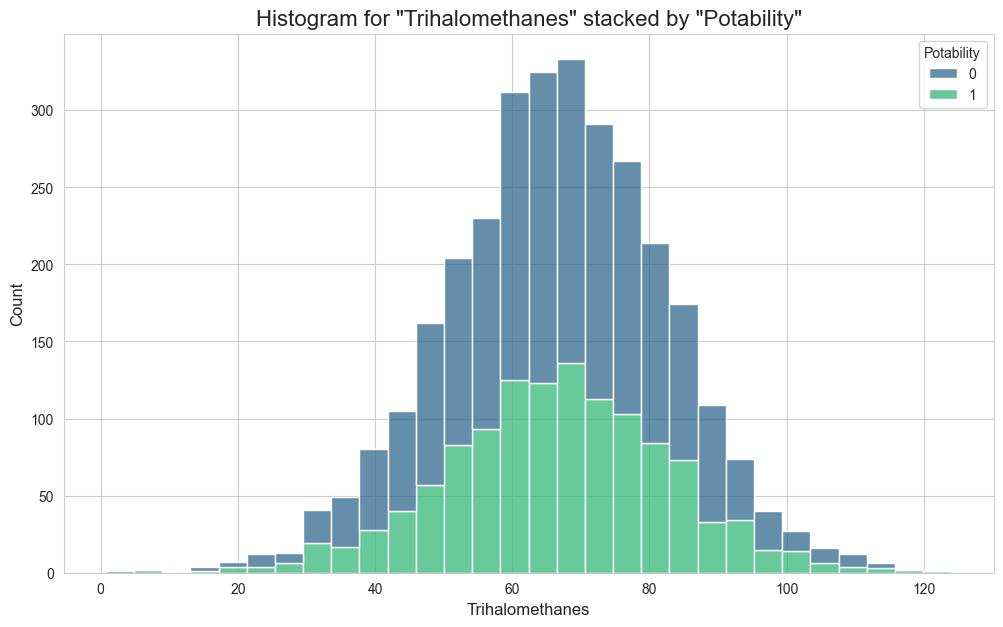

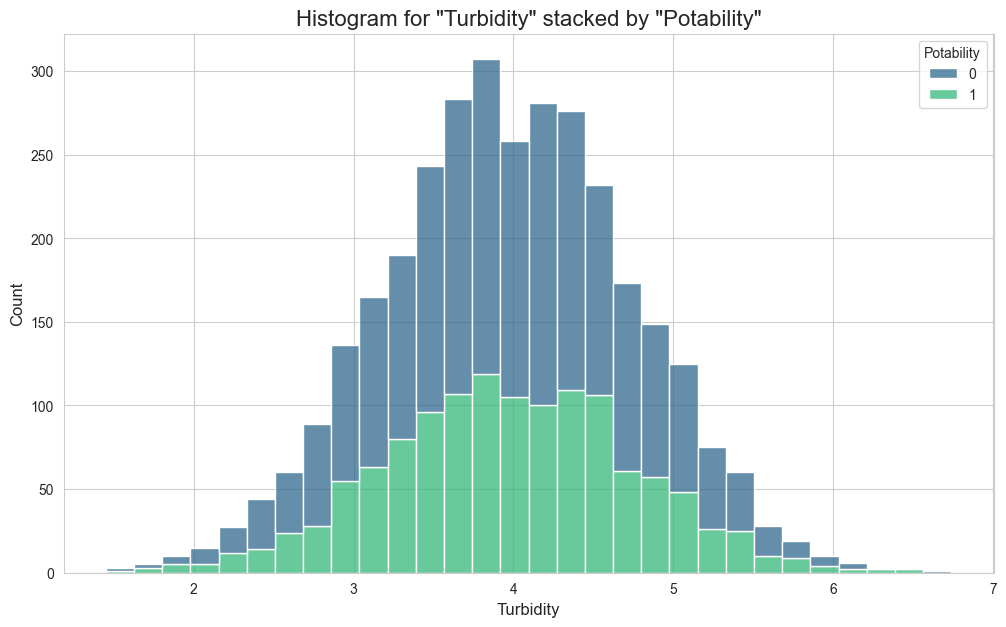


Analysis of stacked histograms:
By observing the plots, we can see how the two classes (0=Not Potable, 1=Potable) are distributed across the range of each feature.
While no single feature perfectly separates the two classes (the colors are mixed in every bar), we can spot subtle differences. For example, in the 'Sulfate' plot, the proportion of potable water (class 1) seems slightly higher at lower sulfate values.
This confirms our earlier conclusion: a combination of features will be necessary for a good classification model.


In [14]:
numerical_features = df.drop('Potability', axis=1)
target_feature = 'Potability'


for feature in numerical_features.columns:
    plt.figure(figsize=(12, 7))

    # Koristimo sns.histplot sa opcijom multiple='stack'
    sns.histplot(data=df, x=feature, hue=target_feature, multiple='stack', palette='viridis', bins=30)

    plt.title(f'Histogram for "{feature}" stacked by "{target_feature}"', fontsize=16)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.show()

print("\nAnalysis of stacked histograms:")
print("By observing the plots, we can see how the two classes (0=Not Potable, 1=Potable) are distributed across the range of each feature.")
print("While no single feature perfectly separates the two classes (the colors are mixed in every bar), we can spot subtle differences. For example, in the 'Sulfate' plot, the proportion of potable water (class 1) seems slightly higher at lower sulfate values.")
print("This confirms our earlier conclusion: a combination of features will be necessary for a good classification model.")